# 0410 Benchmark Evaluation

Two-stage batch pipeline (Haiku 4.5 + Kimi K2.5) evaluated against the 0410 expert-labeled benchmark.

**Run:** `9f602b16-b55e-4589-83db-6c000e66ce9d` (submitted 2026-05-18)
**Dataset:** `data/benchmark_original/0410.csv` (383 citing clusters × ~38 cited cases = 14.5K label rows; 9,740 after dropping PENDING/REMOVE/MANUAL)
**Pipeline:** `citator-pipeline/run_batch.py run` with production prompts.

Metrics: Precision / Recall / F1 (per-class, macro, weighted), Cohen's κ, quadratic-weighted κ (for ordinal severity + treatment), confusion matrices, coverage. v305 (and 0407) comparisons derive `pred_severity` + `pred_direction` from the canonical treatment via the same mapping 0518 uses — apples-to-apples.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    f1_score,
)

sys.path.insert(0, str(Path('..').resolve() / 'citator-pipeline'))
from utils.eval_utils import severity_mapping, direction_mapping  # noqa: E402
from utils.postprocess import TREATMENT_RANK  # noqa: E402

DATA_DIR = Path('data')
LABELS_FILE = Path('..') / 'data' / 'benchmark_original' / '0410.csv'

pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 80)

## 1. Load data + re-merge predictions with labels

`matched_results.csv` keeps the predicted treatment but drops the label's `final_treatment` / `severity` / `direction`. We re-merge on `(citing_cluster_id, cited_cluster_id)` to get the ground truth back.

In [2]:
matched = pd.read_csv(DATA_DIR / 'eval' / 'matched_results.csv')
label_missed = pd.read_csv(DATA_DIR / 'eval' / 'label_missed.csv')
model_missed = pd.read_csv(DATA_DIR / 'eval' / 'model_missed.csv')
labels = pd.read_csv(LABELS_FILE)

# Filter labels the same way collect() does
labels = labels[~labels['final_treatment'].isin(['PENDING', 'REMOVE', 'MANUAL'])].copy()

# Bring back ground-truth columns
eval_df = matched.merge(
    labels[['citing_cluster_id', 'cited_cluster_id',
            'final_treatment', 'severity', 'direction']],
    on=['citing_cluster_id', 'cited_cluster_id'],
    how='inner',
    suffixes=('_pred', '_true'),
).rename(columns={
    'treatment': 'pred_treatment',
    'caseHistory': 'pred_direction',
    'severity_pred': 'pred_severity',
    'final_treatment': 'true_treatment',
    'severity_true': 'true_severity',
    'direction': 'true_direction',
})

# Predicted severity + direction come from the postprocess override (both
# derived from the canonical treatment string via TREATMENT_RANK /
# severity_mapping / direction_mapping). The model's own `caseHistory` output
# is intentionally discarded in postprocess so direction stays a deterministic
# function of treatment — matching how the 0410 labels were built.

print(f'Matched (eval set): {len(eval_df):,} rows')
eval_df[['citing_cluster_id', 'pred_treatment', 'true_treatment',
         'pred_severity', 'true_severity',
         'pred_direction', 'true_direction']].head(3)

Matched (eval set): 8,856 rows


,citing_cluster_id,pred_treatment,true_treatment,pred_severity,true_severity,pred_direction,true_direction
0,103496,Reversed by,Affirmed by,Stop,Neutral,Direct History,Direct History
1,118310,Reversed by,Reversed and remanded by,Stop,Stop,Direct History,Direct History
2,110518,Reversed as recognized by,Cited by,Stop,Neutral,Related Reference,Citing Reference


In [3]:
def _treatment_rank(t):
    """Map a treatment string to its TREATMENT_RANK value. Strips
    'as recognized by' first since TREATMENT_RANK is keyed on base treatments.
    Returns None if the treatment isn't in the canonical taxonomy."""
    if pd.isna(t) or not t:
        return None
    base = t.replace(' as recognized by', ' by') if ' as recognized' in t else t
    return TREATMENT_RANK.get(base)


# Ordinal distance between predicted and true treatment on the TREATMENT_RANK
# scale (0 = most negative `Reversed by`, 21 = most neutral `Cited by`).
#   Distance 0   = exact match
#   Distance 1-3 = typically within-severity-tier confusion (e.g. Reversed by ↔ Vacated by)
#   Distance 4-10 = crossed adjacent tiers
#   Distance >10 = crossed multiple tiers (e.g. Stop ↔ Neutral)
#   NaN = at least one side wasn't in the canonical taxonomy
eval_df['true_rank']               = eval_df['true_treatment'].apply(_treatment_rank)
eval_df['pred_rank']               = eval_df['pred_treatment'].apply(_treatment_rank)
eval_df['treatment_rank_distance'] = (eval_df['pred_rank'] - eval_df['true_rank']).abs()

# Distribution
n_total = len(eval_df)
n_valid = eval_df['treatment_rank_distance'].notna().sum()
print(f'Rows with computable distance: {n_valid:,} / {n_total:,}')
print()
print('Distance distribution (full 0518 eval):')
dist_counts = eval_df['treatment_rank_distance'].value_counts().sort_index()
denom = dist_counts.sum()
for d, n in dist_counts.items():
    bar = '█' * int(60 * n / denom)
    print(f'  {int(d):2d}: {n:>5,} ({n/denom:5.1%}) {bar}')
print()
print(f'Mean distance:   {eval_df["treatment_rank_distance"].mean():.2f}')
print(f'Median distance: {eval_df["treatment_rank_distance"].median():.0f}')
print(f'Max distance:    {eval_df["treatment_rank_distance"].max():.0f}')

eval_df[['citing_cluster_id', 'cited_cluster_id', 'true_treatment', 'pred_treatment',
         'true_rank', 'pred_rank', 'treatment_rank_distance']].head(5)


Rows with computable distance: 8,856 / 8,856

Distance distribution (full 0518 eval):
   0: 8,365 (94.5%) ████████████████████████████████████████████████████████
   1:    77 ( 0.9%) 
   2:    40 ( 0.5%) 
   3:     5 ( 0.1%) 
   4:     8 ( 0.1%) 
   5:   234 ( 2.6%) █
   6:     9 ( 0.1%) 
   7:     2 ( 0.0%) 
   8:     4 ( 0.0%) 
   9:     2 ( 0.0%) 
  10:    17 ( 0.2%) 
  11:     6 ( 0.1%) 
  12:     4 ( 0.0%) 
  13:     5 ( 0.1%) 
  14:     2 ( 0.0%) 
  15:     2 ( 0.0%) 
  16:    16 ( 0.2%) 
  17:    22 ( 0.2%) 
  18:     7 ( 0.1%) 
  19:    13 ( 0.1%) 
  20:     5 ( 0.1%) 
  21:    11 ( 0.1%) 

Mean distance:   0.37
Median distance: 0
Max distance:    21


,citing_cluster_id,cited_cluster_id,true_treatment,pred_treatment,true_rank,pred_rank,treatment_rank_distance
0,103496,1682374.0,Affirmed by,Reversed by,19,0,19
1,118310,7038490.0,Reversed and remanded by,Reversed by,1,0,1
2,110518,109620.0,Cited by,Reversed as recognized by,21,0,21
3,110226,360990.0,Reversed by,Reversed by,0,0,0
4,2540705,6987445.0,Vacated and remanded by,Reversed by,2,0,2


In [4]:
# Top confusion pairs at rank distance >= 5 — these are the costliest errors
# (within-tier confusions are distance 1-3; distance >= 5 typically crosses
# severity tiers and inverts the severity signal for downstream consumers).
def _norm(t):
    if pd.isna(t) or not t: return None
    return t.replace(' as recognized by', ' by') if ' as recognized' in t else t

_far = eval_df[eval_df['treatment_rank_distance'] >= 5].copy()
_far['true_base'] = _far['true_treatment'].apply(_norm)
_far['pred_base'] = _far['pred_treatment'].apply(_norm)

print(f'Rows at distance >= 5: {len(_far):,} ({len(_far)/len(eval_df):.1%} of all rows)')
print()
print('Top 15 (true → pred, with rank distance):')
pair_counts = (_far.groupby(['true_base', 'pred_base', 'treatment_rank_distance'])
                    .size().sort_values(ascending=False).head(5))
print(pair_counts.to_string())


Rows at distance >= 5: 361 (4.1% of all rows)

Top 15 (true → pred, with rank distance):
true_base         pred_base         treatment_rank_distance
Cited by          Distinguished by  5                          175
Distinguished by  Cited by          5                           54
Cited by          Overruled by      17                          16
Abrogated by      Cited by          16                          14
Cited by          Limited by        10                          12


## 2. Coverage

How much of the benchmark did the model actually see? Three buckets:

- **Matched** — model predicted a treatment for a citation that has a label. (used for all classification metrics below)
- **Label missed** — model predicted a treatment for a citation **not** in the labels (could be a real citation the labels don't cover, or a hallucinated citation).
- **Model missed** — a label exists but the model didn't extract / predict the citation (a recall miss in Stage 1).

In [5]:
n_matched = len(matched)
n_label_missed = len(label_missed)
n_model_missed = len(model_missed)
n_labels = len(labels)

# Labels we actually covered = labels whose (citing, cited) keys appear in matched
matched_keys = set(zip(matched['citing_cluster_id'], matched['cited_cluster_id']))
label_keys = set(zip(labels['citing_cluster_id'], labels['cited_cluster_id']))
label_coverage = len(matched_keys & label_keys) / len(label_keys) if label_keys else 0

coverage = pd.DataFrame({
    'count': [n_matched, n_label_missed, n_model_missed, n_labels],
    'description': [
        'Model predictions matched to a label',
        'Model predictions with no matching label',
        'Labels the model did not predict (Stage 1 / matching miss)',
        'Total benchmark labels (after PENDING/REMOVE/MANUAL filter)',
    ],
}, index=['matched', 'label_missed', 'model_missed', 'total_labels'])

print(f'Label coverage: {label_coverage:.1%}  ({len(matched_keys & label_keys):,} of {len(label_keys):,} labels)')
print()
coverage

Label coverage: 90.9%  (8,836 of 9,720 labels)



,count,description
matched,8836,Model predictions matched to a label
label_missed,3720,Model predictions with no matching label
model_missed,246,Labels the model did not predict (Stage 1 / matching miss)
total_labels,9740,Total benchmark labels (after PENDING/REMOVE/MANUAL filter)


## 4. Treatment-level metrics

Predictions normalized by stripping `as recognized by` to match the label's treatment form (labels in `0410.csv` are base treatments, not RR forms).

In [6]:
def normalize_treatment(t):
    """Strip 'as recognized by' modifier so RR forms compare to base treatments in labels."""
    if pd.isna(t) or not t: return ''
    return t.replace(' as recognized by', ' by') if ' as recognized' in t else t

eval_df['pred_treatment_base'] = eval_df['pred_treatment'].apply(normalize_treatment)
eval_df['true_treatment_base'] = eval_df['true_treatment'].apply(normalize_treatment)

y_true = eval_df['true_treatment_base']
y_pred = eval_df['pred_treatment_base']

print(classification_report(y_true, y_pred, zero_division=0))
print()
print(f"Macro F1:    {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Accuracy:    {(y_true == y_pred).mean():.4f}")
print(f"Cohen's κ:   {cohen_kappa_score(y_true, y_pred):.4f}")

# Quadratic weighted κ using TREATMENT_RANK as the ordinal scale.
# TREATMENT_RANK: 0 (most negative, Reversed by) → 21 (most neutral, Cited by).
# QWK penalizes near-misses (e.g. Reversed by ↔ Vacated by, ranks 0↔3) lightly
# and far-misses (Reversed by ↔ Cited by, ranks 0↔21) heavily.
y_true_tr = y_true.map(TREATMENT_RANK)
y_pred_tr = y_pred.map(TREATMENT_RANK)
valid = y_true_tr.notna() & y_pred_tr.notna()
n_dropped = (~valid).sum()
qwk_t = cohen_kappa_score(
    y_true_tr[valid].astype(int),
    y_pred_tr[valid].astype(int),
    weights='quadratic',
)
print(f"Quadratic weighted κ:  {qwk_t:.4f}  ({valid.sum():,} rows, {n_dropped} dropped for unmappable treatment)")

                                       precision    recall  f1-score   support

                         Abrogated by       0.00      0.00      0.00        17
                          Affirmed by       0.68      0.60      0.64        81
Affirmed in part; Reversed in part by       0.30      1.00      0.46         3
                      Cert. denied by       0.59      0.74      0.65        87
                     Cert. granted by       0.20      0.50      0.29         2
                             Cited by       0.98      0.96      0.97      8327
                        Criticized by       0.18      0.67      0.29         3
                Declined to follow by       0.33      0.33      0.33         3
                       Disapproved by       0.00      0.00      0.00         3
                         Dismissed by       0.50      1.00      0.67         4
                     Distinguished by       0.42      0.70      0.53       194
                           Limited by       0.16   

### Treatment confusion matrix

Focused on the top-N most-common treatments (in true labels) so the heatmap stays readable.

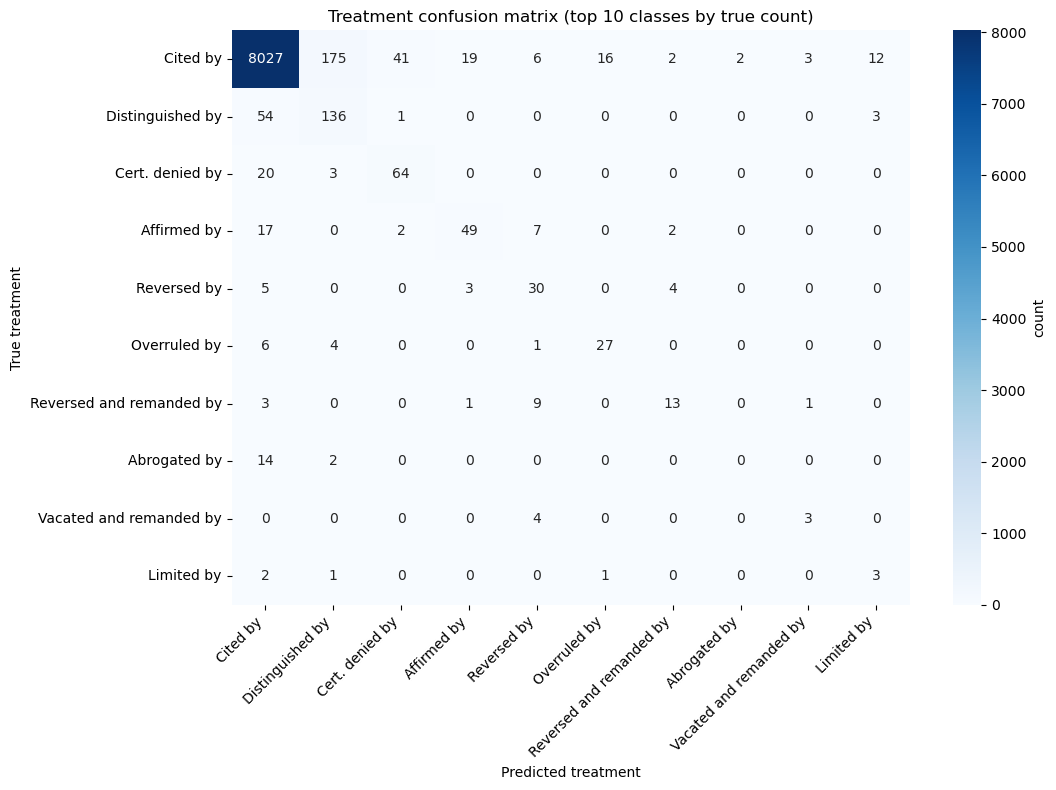

Coverage of confusion matrix: 8,798 / 8,856 rows (99.3%)


In [7]:
TOP_N = 10
top_treatments = y_true.value_counts().head(TOP_N).index.tolist()
mask = y_true.isin(top_treatments) & y_pred.isin(top_treatments)
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_treatments)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_treatments, yticklabels=top_treatments,
            cbar_kws={'label': 'count'}, ax=ax)
ax.set_xlabel('Predicted treatment')
ax.set_ylabel('True treatment')
ax.set_title(f'Treatment confusion matrix (top {TOP_N} classes by true count)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Coverage of confusion matrix: {mask.sum():,} / {len(eval_df):,} rows ({mask.mean():.1%})')

## 5. Severity-level metrics

Severity is ordinal: **Stop > Warning > Caution > Neutral**. Quadratic weighted κ is the right agreement statistic here — it penalizes Stop↔Neutral much more than Stop↔Warning.

In [8]:
SEVERITY_ORDER = ['Stop', 'Warning', 'Caution', 'Neutral']
SEVERITY_TO_RANK = {s: i for i, s in enumerate(reversed(SEVERITY_ORDER))}  # Neutral=0, Stop=3

y_true_s = eval_df['true_severity']
y_pred_s = eval_df['pred_severity']

print(classification_report(y_true_s, y_pred_s, labels=SEVERITY_ORDER, zero_division=0))
print()
print(f"Macro F1:                 {f1_score(y_true_s, y_pred_s, average='macro', zero_division=0):.4f}")
print(f"Weighted F1:              {f1_score(y_true_s, y_pred_s, average='weighted', zero_division=0):.4f}")
print(f"Accuracy:                 {(y_true_s == y_pred_s).mean():.4f}")
print(f"Cohen's κ:                {cohen_kappa_score(y_true_s, y_pred_s):.4f}")

y_true_rank = y_true_s.map(SEVERITY_TO_RANK).dropna()
y_pred_rank = y_pred_s.map(SEVERITY_TO_RANK).reindex(y_true_rank.index).dropna()
common = y_true_rank.index.intersection(y_pred_rank.index)
qwk = cohen_kappa_score(y_true_rank.loc[common], y_pred_rank.loc[common], weights='quadratic')
print(f"Quadratic weighted κ:     {qwk:.4f}")

              precision    recall  f1-score   support

        Stop       0.68      0.67      0.67       142
     Warning       0.19      0.46      0.27        13
     Caution       0.41      0.69      0.51       202
     Neutral       0.99      0.97      0.98      8499

    accuracy                           0.96      8856
   macro avg       0.57      0.70      0.61      8856
weighted avg       0.97      0.96      0.96      8856


Macro F1:                 0.6095
Weighted F1:              0.9629
Accuracy:                 0.9584
Cohen's κ:                0.5630
Quadratic weighted κ:     0.6556


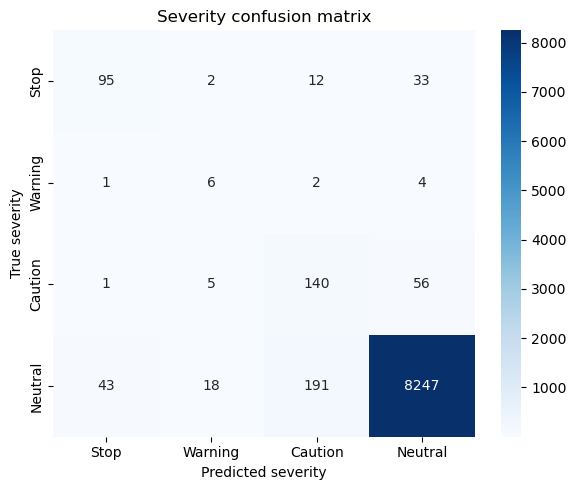

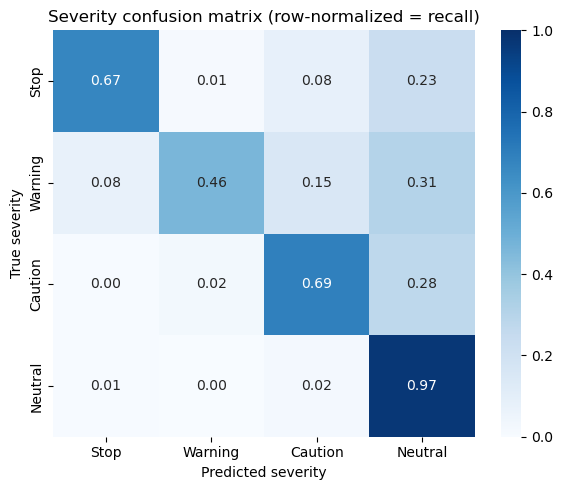

In [9]:
cm_s = confusion_matrix(y_true_s, y_pred_s, labels=SEVERITY_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=SEVERITY_ORDER, yticklabels=SEVERITY_ORDER, ax=ax)
ax.set_xlabel('Predicted severity')
ax.set_ylabel('True severity')
ax.set_title('Severity confusion matrix')
plt.tight_layout()
plt.show()

# Normalized version (recall per row) to spot which severities are hard to recover
cm_s_norm = cm_s / cm_s.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_s_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=SEVERITY_ORDER, yticklabels=SEVERITY_ORDER, ax=ax)
ax.set_xlabel('Predicted severity')
ax.set_ylabel('True severity')
ax.set_title('Severity confusion matrix (row-normalized = recall)')
plt.tight_layout()
plt.show()

## 6. Direction-level metrics

Direction is nominal: **Direct History / Citing Reference / Related Reference**. No ordinal weighting applies.

In [10]:
DIRECTION_ORDER = ['Direct History', 'Citing Reference', 'Related Reference']
y_true_d = eval_df['true_direction']
y_pred_d = eval_df['pred_direction']

print(classification_report(y_true_d, y_pred_d, labels=DIRECTION_ORDER, zero_division=0))
print()
print(f"Macro F1:    {f1_score(y_true_d, y_pred_d, average='macro', zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_true_d, y_pred_d, average='weighted', zero_division=0):.4f}")
print(f"Accuracy:    {(y_true_d == y_pred_d).mean():.4f}")
print(f"Cohen's κ:   {cohen_kappa_score(y_true_d, y_pred_d):.4f}")

                   precision    recall  f1-score   support

   Direct History       0.81      0.83      0.82       109
 Citing Reference       0.99      0.99      0.99      8547
Related Reference       0.57      0.69      0.62       200

         accuracy                           0.98      8856
        macro avg       0.79      0.84      0.81      8856
     weighted avg       0.98      0.98      0.98      8856


Macro F1:    0.8124
Weighted F1: 0.9793
Accuracy:    0.9784
Cohen's κ:   0.7020


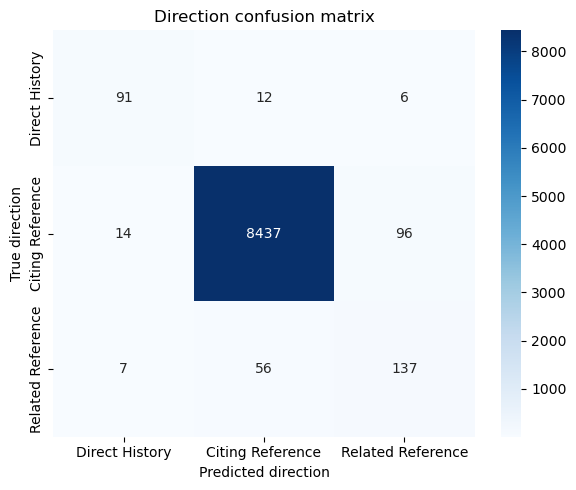

In [11]:
cm_d = confusion_matrix(y_true_d, y_pred_d, labels=DIRECTION_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=DIRECTION_ORDER, yticklabels=DIRECTION_ORDER, ax=ax)
ax.set_xlabel('Predicted direction')
ax.set_ylabel('True direction')
ax.set_title('Direction confusion matrix')
plt.tight_layout()
plt.show()

## 7. Summary

In [12]:
rows = []
for level, yt, yp, ordered_for_qwk in [
    ('Treatment', y_true, y_pred, TREATMENT_RANK),
    ('Severity',  y_true_s, y_pred_s, SEVERITY_TO_RANK),
    ('Direction', y_true_d, y_pred_d, None),
]:
    macro = f1_score(yt, yp, average='macro', zero_division=0)
    weighted = f1_score(yt, yp, average='weighted', zero_division=0)
    acc = (yt == yp).mean()
    kappa = cohen_kappa_score(yt, yp)
    qwk_v = ''
    if ordered_for_qwk is not None:
        yt_r = yt.map(ordered_for_qwk)
        yp_r = yp.map(ordered_for_qwk)
        valid = yt_r.notna() & yp_r.notna()
        qwk_v = f"{cohen_kappa_score(yt_r[valid].astype(int), yp_r[valid].astype(int), weights='quadratic'):.4f}"
    rows.append({
        'level': level,
        'accuracy': f'{acc:.4f}',
        'macro_F1': f'{macro:.4f}',
        'weighted_F1': f'{weighted:.4f}',
        "Cohen's κ": f'{kappa:.4f}',
        'quadratic_κ': qwk_v or '—',
    })
summary = pd.DataFrame(rows).set_index('level')
summary

,accuracy,macro_F1,weighted_F1,Cohen's κ,quadratic_κ
level,,,,,
Treatment,0.9446,0.3821,0.9488,0.5848,0.6953
Severity,0.9584,0.6095,0.9629,0.5630,0.6556
Direction,0.9784,0.8124,0.9793,0.7020,—


## 7b. Federal appellate top-line (0518 only — production focus)

Since the citator's first production target is **federal appellate** opinions, this section recomputes the §4–§7 metric inventory restricted to citing clusters in `{scotus, ca1–ca11, cadc, cafc}`. Same eval_df, just filtered. This is the production-grade headline number for the 0518 pipeline.

The fed-appellate slice on the full 0518 matched_results: **6,375 rows / 188 distinct citing clusters** (175 SCOTUS, 9 ca2, 2 cadc, 1 ca4, 1 ca3). Comprises 72% of all matched_results rows but only 49% of distinct citing clusters — fed-appellate opinions cite more cases on average than the long-tail state/district courts in the benchmark.

In [13]:
FED_APPELLATE_COURTS = {
    'scotus',
    'ca1', 'ca2', 'ca3', 'ca4', 'ca5', 'ca6', 'ca7', 'ca8', 'ca9',
    'ca10', 'ca11', 'cadc', 'cafc',
}
_courts_df = pd.read_csv('../data/benchmark_original/cluster_courts.csv')
fed_app_cluster_ids = set(
    _courts_df[_courts_df['court'].isin(FED_APPELLATE_COURTS)]['cluster_id']
)

eval_fed = eval_df[eval_df['citing_cluster_id'].isin(fed_app_cluster_ids)].copy()
print(f"Fed-appellate eval slice: {len(eval_fed):,} rows / "
      f"{eval_fed['citing_cluster_id'].nunique()} citing clusters")
print()
print("True direction distribution on the fed-appellate slice:")
print(eval_fed['true_direction'].value_counts().to_string())
print()
print("True severity distribution on the fed-appellate slice:")
print(eval_fed['true_severity'].value_counts().to_string())

Fed-appellate eval slice: 6,375 rows / 188 citing clusters

True direction distribution on the fed-appellate slice:
true_direction
Citing Reference     6086
Related Reference     180
Direct History        109

True severity distribution on the fed-appellate slice:
true_severity
Neutral    6044
Caution     184
Stop        134
Warning      13


In [14]:
# Same summary table format as §7 — restricted to the fed-appellate slice.
y_true_fed   = eval_fed['true_treatment_base']  if 'true_treatment_base' in eval_fed.columns else eval_fed['true_treatment'].apply(normalize_treatment)
y_pred_fed   = eval_fed['pred_treatment_base']  if 'pred_treatment_base' in eval_fed.columns else eval_fed['pred_treatment'].apply(normalize_treatment)
y_true_s_fed = eval_fed['true_severity']
y_pred_s_fed = eval_fed['pred_severity']
y_true_d_fed = eval_fed['true_direction']
y_pred_d_fed = eval_fed['pred_direction']

rows = []
for level, yt, yp, ordered_for_qwk in [
    ('Treatment', y_true_fed,   y_pred_fed,   TREATMENT_RANK),
    ('Severity',  y_true_s_fed, y_pred_s_fed, SEVERITY_TO_RANK),
    ('Direction', y_true_d_fed, y_pred_d_fed, None),
]:
    macro = f1_score(yt, yp, average='macro', zero_division=0)
    weighted = f1_score(yt, yp, average='weighted', zero_division=0)
    acc = (yt == yp).mean()
    kappa = cohen_kappa_score(yt, yp)
    qwk_v = ''
    if ordered_for_qwk is not None:
        yt_r = yt.map(ordered_for_qwk)
        yp_r = yp.map(ordered_for_qwk)
        valid = yt_r.notna() & yp_r.notna()
        qwk_v = f"{cohen_kappa_score(yt_r[valid].astype(int), yp_r[valid].astype(int), weights='quadratic'):.4f}"
    rows.append({
        'level': level,
        'accuracy':     f'{acc:.4f}',
        'macro_F1':     f'{macro:.4f}',
        'weighted_F1':  f'{weighted:.4f}',
        "Cohen's κ":    f'{kappa:.4f}',
        'quadratic_κ':  qwk_v or '—',
    })
summary_fed = pd.DataFrame(rows).set_index('level')
summary_fed

,accuracy,macro_F1,weighted_F1,Cohen's κ,quadratic_κ
level,,,,,
Treatment,0.9318,0.3951,0.9362,0.5920,0.7205
Severity,0.9485,0.6222,0.9538,0.5690,0.6828
Direction,0.9754,0.8245,0.9761,0.7311,—


In [15]:
# DH vs Other split on the fed-appellate slice (0518 only)
eval_fed_dh    = eval_fed[eval_fed['true_direction'] == 'Direct History'].copy()
eval_fed_other = eval_fed[eval_fed['true_direction'] != 'Direct History'].copy()

print(f"Direct History rows: {len(eval_fed_dh)}")
print(f"Other rows:          {len(eval_fed_other):,}")
print()
print("Direct History true_treatment distribution on fed-appellate:")
print(eval_fed_dh['true_treatment'].value_counts().to_string())

Direct History rows: 109
Other rows:          6,266

Direct History true_treatment distribution on fed-appellate:
true_treatment
Affirmed by                              39
Reversed by                              34
Reversed and remanded by                 26
Vacated and remanded by                   5
Affirmed in part; Reversed in part by     3
Vacated by                                1
Dismissed by                              1


In [16]:
def _summary_row(label, df):
    """Same metric layout as the §7 summary, for an arbitrary subset df."""
    yt = df['true_treatment'].apply(normalize_treatment)
    yp = df['pred_treatment'].apply(normalize_treatment)
    yt_r, yp_r = yt.map(TREATMENT_RANK), yp.map(TREATMENT_RANK)
    vt = yt_r.notna() & yp_r.notna()
    sev_t = df['true_severity'].map(SEVERITY_TO_RANK)
    sev_p = df['pred_severity'].map(SEVERITY_TO_RANK)
    vs = sev_t.notna() & sev_p.notna()
    return {
        'slice': label,
        'rows': len(df),
        'tr_macroF1': f1_score(yt, yp, average='macro', zero_division=0),
        'tr_weightedF1': f1_score(yt, yp, average='weighted', zero_division=0),
        'tr_kappa': cohen_kappa_score(yt, yp),
        'tr_QWK': cohen_kappa_score(yt_r[vt].astype(int), yp_r[vt].astype(int),
                                    weights='quadratic') if vt.sum() else None,
        'sev_macroF1': f1_score(df['true_severity'], df['pred_severity'],
                                average='macro', zero_division=0),
        'sev_kappa': cohen_kappa_score(df['true_severity'], df['pred_severity']),
        'sev_QWK': cohen_kappa_score(sev_t[vs].astype(int), sev_p[vs].astype(int),
                                     weights='quadratic') if vs.sum() else None,
        'dir_macroF1': f1_score(df['true_direction'], df['pred_direction'],
                                average='macro', zero_division=0),
        'dir_kappa': cohen_kappa_score(df['true_direction'], df['pred_direction']),
    }


fed_split = pd.DataFrame([
    _summary_row('fed-app aggregate', eval_fed),
    _summary_row('fed-app DH',        eval_fed_dh),
    _summary_row('fed-app Other',     eval_fed_other),
]).set_index('slice')
fed_split.round(4).T

slice,fed-app aggregate,fed-app DH,fed-app Other
rows,6375.0000,109.0000,6266.0000
tr_macroF1,0.3951,0.3307,0.3904
tr_weightedF1,0.9362,0.5816,0.9433
tr_kappa,0.5920,0.3975,0.5606
tr_QWK,0.7205,0.5610,0.6079
sev_macroF1,0.6222,0.5368,0.5753
sev_kappa,0.5690,0.5499,0.5235
sev_QWK,0.6828,0.5868,0.5928
dir_macroF1,0.8245,0.3033,0.5525
dir_kappa,0.7311,0.0000,0.6417


## 8. Apples-to-apples comparison: v305 vs 0518

Production two-stage pipeline (0518: Haiku 4.5 + Kimi K2.5) vs the strongest prior single-stage Sonnet baseline (v305 from `experiments_02252026`, March 2026). v305's `matched_results.csv` is re-merged against the 0410 labels (originally joined to 317 labels; ~6% drift). 2-way citing-cluster overlap, identical normalization.

| Pipeline | Model | Prompt | Stage |
|---|---|---|---|
| **v305** | Sonnet 4.6 | v305 instructions | single-stage |
| **0518** | Haiku 4.5 + Kimi K2.5 | `haiku_extractor` + `kimi_classifier` | two-stage batch |

In [17]:
import glob


# ─── Helpers for treatment normalization + heuristic mapping ───
# Defined here so the v305 load step can apply the same severity/direction
# override that 0518's postprocess does (Phase 8). The metric cell below
# reuses these.

def _normalize_treatment(t):
    if pd.isna(t) or not t: return ''
    return t.replace(' as recognized by', ' by') if ' as recognized' in t else t


def _derive_severity_from_treatment(t):
    if pd.isna(t) or not t: return 'Unknown'
    return severity_mapping.get(_normalize_treatment(t), 'Unknown')


def _derive_direction_from_treatment(t):
    if pd.isna(t) or not t: return 'Unknown'
    if ' as recognized by' in t: return 'Related Reference'
    return direction_mapping.get(t, 'Unknown')


def _load_v305_predictions():
    """Load v305 prediction columns from matched_results across all 4 buckets.

    Strips the 317-benchmark label columns so we can re-merge against 0410.
    """
    paths = sorted(glob.glob(
        '../experiments_02252026/data/eval/v305/*_citing_ids/matched_results.csv'
    ))
    parts = []
    for p in paths:
        d = pd.read_csv(p)
        keep = [c for c in d.columns
                if c not in {'final_treatment', 'severity', 'direction'}]
        parts.append(d[keep])
    df = pd.concat(parts, ignore_index=True)
    return df.rename(columns={
        'targetTreatment': 'pred_treatment',
        'targetHistory':   'pred_direction_raw',  # model's caseHistory output, not used in metrics
    })


# v305 predictions + 0410 labels (re-merged for apples-to-apples).
v305_pred = _load_v305_predictions()
v305_df = v305_pred.merge(
    labels[['citing_cluster_id', 'cited_cluster_id',
            'final_treatment', 'severity', 'direction']],
    on=['citing_cluster_id', 'cited_cluster_id'],
    how='inner',
).rename(columns={
    'final_treatment': 'true_treatment',
    'severity': 'true_severity',
    'direction': 'true_direction',
})

# Apply the same severity/direction override that 0518's postprocess does
# (Phase 8) — derive from canonical treatment, discard the model's raw
# caseHistory output. Both pipelines now use heuristic-derived severity and
# direction at the DATA level, not just inside pipeline_metrics.
v305_df['pred_severity']  = v305_df['pred_treatment'].apply(_derive_severity_from_treatment)
v305_df['pred_direction'] = v305_df['pred_treatment'].apply(_derive_direction_from_treatment)

# 0518 frame already has pred_severity/pred_direction baked in (via Phase 8
# postprocess), but the column names differ — surface them under the
# pipeline_metrics-expected names. eval_df came from §1.
v518_df = eval_df.copy()

# Drop rows with missing labels or preds so metrics aren't polluted by NaN.
for d in (v305_df, v518_df):
    d.dropna(
        subset=['true_treatment', 'true_severity', 'true_direction', 'pred_treatment'],
        inplace=True,
    )

# 2-way citing-cluster overlap
overlap_ids = set(v305_df['citing_cluster_id']) & set(v518_df['citing_cluster_id'])
v305_o = v305_df[v305_df['citing_cluster_id'].isin(overlap_ids)].copy()
v518_o = v518_df[v518_df['citing_cluster_id'].isin(overlap_ids)].copy()

print(f'Citing-cluster overlap (v305 ∩ 0518): {len(overlap_ids)} clusters')
print(f'Row counts on overlap (after dropping NaN labels/preds): '
      f'v305={len(v305_o):,}, 0518={len(v518_o):,}')

# Quick visibility: how often does v305's raw direction (model output) agree
# with the treatment-derived override? (For documentation; not used in metrics.)
ch_present = v305_o['pred_direction_raw'].notna() & (v305_o['pred_direction_raw'] != '')
ch_agree   = ch_present & (v305_o['pred_direction_raw'] == v305_o['pred_direction'])
if ch_present.sum():
    print(f"v305 raw caseHistory vs treatment-derived direction: "
          f"{ch_agree.sum():,}/{ch_present.sum():,} agree = "
          f"{ch_agree.sum() / ch_present.sum():.1%}  (raw output kept for inspection only)")

Citing-cluster overlap (v305 ∩ 0518): 252 clusters
Row counts on overlap (after dropping NaN labels/preds): v305=6,157, 0518=6,186
v305 raw caseHistory vs treatment-derived direction: 6,141/6,157 agree = 99.7%  (raw output kept for inspection only)


In [18]:
def pipeline_metrics(name, df):
    """Compute the trim metric inventory at all three levels.

    and Quadratic-weighted κ where the labels are ordinal (severity, treatment).

    Cohen's κ measures agreement above chance using the marginal class
    different baseline that is robust to high-prevalence skew. The two often
    high. Reporting both lets you see how much of the agreement is "real"
    vs. driven by the dominant class.

    Expects `df` to have these columns:
      - true_treatment, pred_treatment   (raw, canonicalized in-place below)
      - true_severity, pred_severity     (heuristic-derived from canonical treatment)
      - true_direction, pred_direction   (heuristic-derived from canonical treatment)
    """
    df = df.copy()
    df['ptn'] = df['pred_treatment'].apply(_normalize_treatment)
    df['ttn'] = df['true_treatment'].apply(_normalize_treatment)

    yt, yp = df['ttn'], df['ptn']
    yt_r, yp_r = yt.map(TREATMENT_RANK), yp.map(TREATMENT_RANK)
    vt = yt_r.notna() & yp_r.notna()
    sev_t = df['true_severity'].map(SEVERITY_TO_RANK)
    sev_p = df['pred_severity'].map(SEVERITY_TO_RANK)
    vs = sev_t.notna() & sev_p.notna()

    return {
        'pipeline': name,
        'rows': len(df),
        # Treatment-level
        'tr_macroF1':    f1_score(yt, yp, average='macro', zero_division=0),
        'tr_weightedF1': f1_score(yt, yp, average='weighted', zero_division=0),
        'tr_kappa':      cohen_kappa_score(yt, yp),
        'tr_QWK': (
            cohen_kappa_score(yt_r[vt].astype(int), yp_r[vt].astype(int),
                              weights='quadratic')
            if vt.sum() else None
        ),
        # Severity-level
        'sev_macroF1':    f1_score(df['true_severity'], df['pred_severity'],
                                   average='macro', zero_division=0),
        'sev_kappa':      cohen_kappa_score(df['true_severity'], df['pred_severity']),
        'sev_QWK':        cohen_kappa_score(sev_t[vs].astype(int), sev_p[vs].astype(int),
                                            weights='quadratic'),
        # Direction-level (nominal — only unweighted κ)
        'dir_macroF1': f1_score(df['true_direction'], df['pred_direction'],
                                average='macro', zero_division=0),
        'dir_kappa':   cohen_kappa_score(df['true_direction'], df['pred_direction']),
    }


comparison = pd.DataFrame([
    pipeline_metrics('v305 (Sonnet 1-stage)', v305_o),
    pipeline_metrics('0518 (Haiku+Kimi 2-stage batch)', v518_o),
]).set_index('pipeline')
comparison.round(4).T

pipeline,v305 (Sonnet 1-stage),0518 (Haiku+Kimi 2-stage batch)
rows,6157.0000,6186.0000
tr_macroF1,0.4612,0.3914
tr_weightedF1,0.9543,0.9467
tr_kappa,0.6045,0.5810
tr_QWK,0.7316,0.6937
sev_macroF1,0.5529,0.6092
sev_kappa,0.7394,0.5515
sev_QWK,0.6905,0.6516
dir_macroF1,0.4780,0.8170
dir_kappa,0.4573,0.7066


## 9. Direct History vs Other — split eval (v305 vs 0518)

Splits the comparison by `true_direction`. Direct History = the cited case is on appeal; treatment is the appellate disposition. Other = Citing/Related Reference; treatment is how the citing court characterizes the cite. Aggregate metrics can mask very different performance on each. Same 2-way overlap, same normalization as §8.

In [19]:
# Split by true_direction. v305_o and v518_o were already filtered to the
# 2-way overlap and use 0410 labels (re-merged for v305 in §8).
def split_by_direction(df):
    dh = df[df['true_direction'] == 'Direct History'].copy()
    other = df[df['true_direction'] != 'Direct History'].copy()
    return dh, other

v305_dh, v305_other = split_by_direction(v305_o)
v518_dh, v518_other = split_by_direction(v518_o)

print(f"Direct History rows:  v305={len(v305_dh)}, 0518={len(v518_dh)}")
print(f"Other rows:           v305={len(v305_other):,}, 0518={len(v518_other):,}")
print()
print('Direct History — true_treatment distribution (0518):')
print(v518_dh['true_treatment'].value_counts().to_string())

Direct History rows:  v305=73, 0518=78
Other rows:           v305=6,084, 0518=6,108

Direct History — true_treatment distribution (0518):
true_treatment
Reversed by                              26
Affirmed by                              25
Reversed and remanded by                 20
Vacated and remanded by                   3
Affirmed in part; Reversed in part by     2
Vacated by                                1
Dismissed by                              1


In [20]:
dh_table = pd.DataFrame([
    pipeline_metrics('v305 Direct History', v305_dh),
    pipeline_metrics('0518 Direct History', v518_dh),
]).set_index('pipeline')

other_table = pd.DataFrame([
    pipeline_metrics('v305 Other (CR + RR)', v305_other),
    pipeline_metrics('0518 Other (CR + RR)', v518_other),
]).set_index('pipeline')

split_results = pd.concat([dh_table, other_table])
split_results.round(4).T

pipeline,v305 Direct History,0518 Direct History,v305 Other (CR + RR),0518 Other (CR + RR)
rows,73.0000,78.0000,6084.0000,6108.0000
tr_macroF1,0.5611,0.3444,0.3327,0.3943
tr_weightedF1,0.8073,0.5780,0.9555,0.9518
tr_kappa,0.6950,0.4100,0.5184,0.5459
tr_QWK,0.8494,0.5679,0.4629,0.5617
sev_macroF1,0.6387,0.5628,0.5773,0.5609
sev_kappa,0.8642,0.5822,0.6829,0.4987
sev_QWK,0.9035,0.5946,0.4569,0.5467
dir_macroF1,0.3165,0.3129,0.3518,0.5408
dir_kappa,0.0000,0.0000,0.1016,0.6100


## 10. Federal appellate slice (SCOTUS + circuit courts)

The benchmark spans 39 courts, but the production pipeline was tuned on federal-appellate opinions. Filter to citing clusters where the court is in {scotus, ca1–ca11, cadc, cafc} so we can see how each pipeline performs on its "home turf" — and what the state-court / district-court additions in 0410 cost us in aggregate.

Note: on the 252-cluster overlap, this slice is **95% SCOTUS** (133 of 139 clusters); the rest is ca2 (4), cadc (1), ca3 (1). So this is really a SCOTUS-heavy comparison.

In [21]:
FED_APPELLATE = {
    'scotus',
    'ca1', 'ca2', 'ca3', 'ca4', 'ca5', 'ca6', 'ca7', 'ca8', 'ca9',
    'ca10', 'ca11', 'cadc', 'cafc',
}
courts_df = pd.read_csv('../data/benchmark_original/cluster_courts.csv')
fed_cluster_ids = set(
    courts_df[courts_df['court'].isin(FED_APPELLATE)]['cluster_id']
)

v305_fed = v305_o[v305_o['citing_cluster_id'].isin(fed_cluster_ids)].copy()
v518_fed = v518_o[v518_o['citing_cluster_id'].isin(fed_cluster_ids)].copy()

fed_clusters_in_slice = set(v305_fed['citing_cluster_id'])
print(f'Federal appellate citing clusters in the 252-overlap: {len(fed_clusters_in_slice)}')
print(f'Row counts on the fed appellate slice:')
print(f'  v305: {len(v305_fed):,}')
print(f'  0518: {len(v518_fed):,}')
print()
print('Court breakdown of the slice:')
print(courts_df[courts_df['cluster_id'].isin(fed_clusters_in_slice)]['court']
      .value_counts().to_string())

Federal appellate citing clusters in the 252-overlap: 139
Row counts on the fed appellate slice:
  v305: 4,025
  0518: 4,034

Court breakdown of the slice:
court
scotus    133
ca2         4
cadc        1
ca3         1


In [22]:
v305_fed_dh, v305_fed_other = split_by_direction(v305_fed)
v518_fed_dh, v518_fed_other = split_by_direction(v518_fed)

fed_aggregate = pd.DataFrame([
    pipeline_metrics('v305 fed-app aggregate', v305_fed),
    pipeline_metrics('0518 fed-app aggregate', v518_fed),
]).set_index('pipeline')

fed_dh = pd.DataFrame([
    pipeline_metrics('v305 fed-app Direct History', v305_fed_dh),
    pipeline_metrics('0518 fed-app Direct History', v518_fed_dh),
]).set_index('pipeline')

fed_other = pd.DataFrame([
    pipeline_metrics('v305 fed-app Other (CR+RR)', v305_fed_other),
    pipeline_metrics('0518 fed-app Other (CR+RR)', v518_fed_other),
]).set_index('pipeline')

fed_results = pd.concat([fed_aggregate, fed_dh, fed_other])
fed_results.round(4).T

pipeline,v305 fed-app aggregate,0518 fed-app aggregate,v305 fed-app Direct History,0518 fed-app Direct History,v305 fed-app Other (CR+RR),0518 fed-app Other (CR+RR)
rows,4025.0000,4034.0000,73.0000,78.0000,3952.0000,3956.0000
tr_macroF1,0.4421,0.4098,0.5611,0.3444,0.3149,0.4166
tr_weightedF1,0.9372,0.9287,0.8073,0.5780,0.9386,0.9363
tr_kappa,0.6033,0.5902,0.6950,0.4100,0.5050,0.5537
tr_QWK,0.7511,0.7250,0.8494,0.5679,0.4805,0.5977
sev_macroF1,0.5627,0.6263,0.6387,0.5628,0.5905,0.5807
sev_kappa,0.7366,0.5601,0.8642,0.5822,0.6709,0.5024
sev_QWK,0.7107,0.6852,0.9035,0.5946,0.4634,0.5868
dir_macroF1,0.4877,0.8308,0.3165,0.3129,0.3532,0.5536
dir_kappa,0.4895,0.7403,0.0000,0.0000,0.1108,0.6461


## 11. "Cert. denied" collapsed to "Cited by"

`Cert. denied by` is a Neutral-tier Direct History treatment, but functionally it carries no precedential signal — the Supreme Court declined to review and didn't reach the merits. From a citator-user perspective, a cited case with cert. denied is no different from any neutrally-cited case. This section folds both `Cert. denied by` and `Cert. denied as recognized by` into `Cited by` on **both** the labels and the predictions, then recomputes the metric inventory.

Why this matters: Cert. denied is one of the more common labels (96 in the labels, 17 in 0518's predictions before this collapse). The model's accuracy on cert. denied vs Cited by distinction can spuriously inflate or deflate certain metrics depending on how often it confuses the two. Collapsing isolates "did the pipeline catch genuine treatment signals" from "did it correctly identify cert denials as a separate label."

In [23]:
CERT_DENIED_VARIANTS = {
    'Cert. denied by',
    'Cert. denied as recognized by',
}


def fold_cert_denied(df):
    """Return a copy where Cert. denied variants are remapped to Cited by on
    BOTH the true_treatment and pred_treatment columns. Severity and direction
    are re-derived from the remapped treatments (for BOTH sides) so they stay
    consistent with the canonical mapping."""
    out = df.copy()
    for col in ('true_treatment', 'pred_treatment'):
        if col in out.columns:
            out[col] = out[col].where(~out[col].isin(CERT_DENIED_VARIANTS), 'Cited by')
    # Re-derive severity/direction on BOTH sides from the (now-collapsed) treatments.
    if 'true_treatment' in out.columns:
        out['true_severity']  = out['true_treatment'].apply(_derive_severity_from_treatment)
        out['true_direction'] = out['true_treatment'].apply(_derive_direction_from_treatment)
    if 'pred_treatment' in out.columns:
        out['pred_severity']  = out['pred_treatment'].apply(_derive_severity_from_treatment)
        out['pred_direction'] = out['pred_treatment'].apply(_derive_direction_from_treatment)
    return out


def make_comparison(label, v305_df, v518_df):
    """Build a side-by-side metrics table for v305 and 0518 with optional split."""
    v305_dh, v305_other = split_by_direction(v305_df)
    v518_dh, v518_other = split_by_direction(v518_df)
    rows = [
        pipeline_metrics(f'v305 {label} aggregate', v305_df),
        pipeline_metrics(f'0518 {label} aggregate', v518_df),
        pipeline_metrics(f'v305 {label} DH', v305_dh),
        pipeline_metrics(f'0518 {label} DH', v518_dh),
        pipeline_metrics(f'v305 {label} Other', v305_other),
        pipeline_metrics(f'0518 {label} Other', v518_other),
    ]
    return pd.DataFrame(rows).set_index('pipeline').round(4)


# Apply the remapping on the same 252-cluster overlap data
v305_collapsed = fold_cert_denied(v305_o)
v518_collapsed = fold_cert_denied(v518_o)


def shift_counts(name, before):
    n_true_shifted = (before['true_treatment'].isin(CERT_DENIED_VARIANTS)).sum()
    n_pred_shifted = (before['pred_treatment'].isin(CERT_DENIED_VARIANTS)).sum()
    print(f'{name}: shifted {n_true_shifted} true labels and '
          f'{n_pred_shifted} predictions from Cert. denied → Cited by')

shift_counts('v305', v305_o)
shift_counts('0518', v518_o)

v305: shifted 75 true labels and 0 predictions from Cert. denied → Cited by
0518: shifted 74 true labels and 77 predictions from Cert. denied → Cited by


In [24]:
make_comparison('(cert-denied collapsed)', v305_collapsed, v518_collapsed).T

pipeline,v305 (cert-denied collapsed) aggregate,0518 (cert-denied collapsed) aggregate,v305 (cert-denied collapsed) DH,0518 (cert-denied collapsed) DH,v305 (cert-denied collapsed) Other,0518 (cert-denied collapsed) Other
rows,6157.0000,6186.0000,73.0000,78.0000,6084.0000,6108.0000
tr_macroF1,0.4872,0.3760,0.5611,0.3444,0.3526,0.3790
tr_weightedF1,0.9724,0.9533,0.8073,0.5780,0.9738,0.9585
tr_kappa,0.6988,0.5561,0.6950,0.4100,0.6298,0.5048
tr_QWK,0.7314,0.6956,0.8494,0.5679,0.4309,0.5626
sev_macroF1,0.5529,0.6092,0.6387,0.5628,0.5773,0.5609
sev_kappa,0.7394,0.5515,0.8642,0.5822,0.6829,0.4987
sev_QWK,0.6905,0.6516,0.9035,0.5946,0.4569,0.5467
dir_macroF1,0.4927,0.7946,0.3165,0.3129,0.3714,0.5199
dir_kappa,0.5968,0.7100,0.0000,0.0000,0.1719,0.5443


## 12. Same pipeline, different mode — 0407 vs 0518 on the 9-opinion eval set

`experiments_04072026` ran the recommended production config (Haiku 4.5 + Kimi K2.5, two-stage) **on-demand** (not batch) on the canonical 9-opinion expert-annotated eval set. That set's citing clusters: `[101625, 103543, 110274, 110360, 110380, 110420, 117849, 725046, 7774813]`.

All 9 are also in 0518's run. So this is a clean **same-pipeline-different-mode** comparison: 0407 was on-demand (Bedrock Converse API, individual calls) at $0.048/case; 0518 is batch (Bedrock batch inference) at roughly half that. Both pipelines should be functionally equivalent — any metric differences are noise from sampling temperature, Bedrock batch quirks, or prompt updates between April 7 and today.

To keep ground truth identical, both pipelines are re-merged against the **0410 labels** before scoring.

In [25]:
NINE_SET_IDS = {101625, 103543, 110274, 110360, 110380,
                110420, 117849, 725046, 7774813}


def _load_0407():
    """0407 matched_results, schema already matches 0518 (caseHistory + treatment).
    Strip its baked-in label columns so we can re-merge against 0410.
    """
    df = pd.read_csv('../experiments_04072026/data/eval/matched_results.csv')
    keep = [c for c in df.columns
            if c not in {'final_treatment', 'severity', 'direction'}]
    return df[keep].rename(columns={
        'treatment': 'pred_treatment',
        'caseHistory': 'pred_direction_raw',  # 0407 was pre-Phase-8; raw model output
    })


v407_pred = _load_0407()
v407 = v407_pred.merge(
    labels[['citing_cluster_id', 'cited_cluster_id',
            'final_treatment', 'severity', 'direction']],
    on=['citing_cluster_id', 'cited_cluster_id'],
    how='inner',
).rename(columns={
    'final_treatment': 'true_treatment',
    'severity': 'true_severity',
    'direction': 'true_direction',
})

# Apply the Phase 8 override at load time, same as we do for v305 in §8.
v407['pred_severity']  = v407['pred_treatment'].apply(_derive_severity_from_treatment)
v407['pred_direction'] = v407['pred_treatment'].apply(_derive_direction_from_treatment)

# 0518 on the 9-set
v18_9 = eval_df[eval_df['citing_cluster_id'].isin(NINE_SET_IDS)].copy()

# Drop NaN rows (same as everywhere else)
for d in (v407, v18_9):
    d.dropna(
        subset=['true_treatment', 'true_severity', 'true_direction', 'pred_treatment'],
        inplace=True,
    )

print(f'0407 rows on 9-set (after 0410 re-merge + NaN drop): {len(v407):,}')
print(f'0518 rows on 9-set (after NaN drop):                  {len(v18_9):,}')
print()
print('Per-cluster row counts:')
print('  0407:', v407['citing_cluster_id'].value_counts().sort_index().to_dict())
print('  0518:', v18_9['citing_cluster_id'].value_counts().sort_index().to_dict())

0407 rows on 9-set (after 0410 re-merge + NaN drop): 267
0518 rows on 9-set (after NaN drop):                  263

Per-cluster row counts:
  0407: {101625: 15, 103543: 19, 110274: 24, 110360: 53, 110380: 76, 110420: 20, 117849: 22, 725046: 29, 7774813: 9}
  0518: {101625: 15, 103543: 19, 110274: 24, 110360: 55, 110380: 74, 110420: 20, 117849: 22, 725046: 25, 7774813: 9}


In [26]:
v407_dh, v407_other = split_by_direction(v407)
v18_9_dh, v18_9_other = split_by_direction(v18_9)

nine_aggregate = pd.DataFrame([
    pipeline_metrics('0407 (on-demand) aggregate', v407),
    pipeline_metrics('0518 (batch) aggregate', v18_9),
]).set_index('pipeline')

nine_dh = pd.DataFrame([
    pipeline_metrics('0407 Direct History', v407_dh),
    pipeline_metrics('0518 Direct History', v18_9_dh),
]).set_index('pipeline')

nine_other = pd.DataFrame([
    pipeline_metrics('0407 Other (CR+RR)', v407_other),
    pipeline_metrics('0518 Other (CR+RR)', v18_9_other),
]).set_index('pipeline')

nine_results = pd.concat([nine_aggregate, nine_dh, nine_other])
nine_results.round(4).T

/Users/rachel/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/rachel/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


pipeline,0407 (on-demand) aggregate,0518 (batch) aggregate,0407 Direct History,0518 Direct History,0407 Other (CR+RR),0518 Other (CR+RR)
rows,267.0000,263.0000,5.0,5.0,262.0000,258.0000
tr_macroF1,0.6922,0.6959,1.0,1.0,0.6329,0.6507
tr_weightedF1,0.9387,0.9242,1.0,1.0,0.9375,0.9229
tr_kappa,0.8284,0.7941,1.0,1.0,0.8103,0.7724
tr_QWK,0.8745,0.8705,1.0,1.0,0.8179,0.8155
sev_macroF1,0.6664,0.6347,1.0,1.0,0.6606,0.6299
sev_kappa,0.7738,0.7217,1.0,1.0,0.7429,0.6839
sev_QWK,0.8826,0.8893,1.0,1.0,0.8379,0.8509
dir_macroF1,0.9587,0.9733,1.0,1.0,0.9381,0.9599
dir_kappa,0.8954,0.9320,NaN,NaN,0.8761,0.9199


## 13. Pairwise forgiveness — "acceptable" confusion pairs

Recompute metrics treating two specific (true, pred) pairs as correct:
- `Cited by` ↔ `Distinguished by` (within Citing Reference, rank distance 5)
- `Cited by` ↔ `Cert. denied as recognized by` (functionally both neutral)

Other confusions involving those classes (e.g. `Reversed by → Distinguished by`, distance 16) are NOT forgiven. Targeted pair-level forgiveness — preserves the rest of the taxonomy.

In [27]:
ACCEPTABLE_PAIRS = {
    frozenset({'Cited by', 'Distinguished by'}),
    frozenset({'Cited by', 'Cert. denied as recognized by'}),
}


def forgive_acceptable_pairs(df):
    """Return a copy of df where rows whose (true, pred) treatment pair is
    in ACCEPTABLE_PAIRS get pred set equal to true. Severity + direction
    are re-derived from the (now-forgiven) treatments via the canonical
    heuristic mapping.
    """
    out = df.copy()

    def _maybe_forgive(row):
        t, p = row['true_treatment'], row['pred_treatment']
        if pd.isna(t) or pd.isna(p) or t == p:
            return p
        return t if frozenset({t, p}) in ACCEPTABLE_PAIRS else p

    out['pred_treatment'] = out.apply(_maybe_forgive, axis=1)
    out['pred_severity']  = out['pred_treatment'].apply(_derive_severity_from_treatment)
    out['pred_direction'] = out['pred_treatment'].apply(_derive_direction_from_treatment)
    # Refresh rank-distance to reflect the forgiveness
    out['pred_rank'] = out['pred_treatment'].apply(_treatment_rank)
    out['treatment_rank_distance'] = (out['pred_rank'] - out['true_rank']).abs()
    return out


eval_forgiven = forgive_acceptable_pairs(eval_df)
n_forgiven = (eval_df['pred_treatment'] != eval_forgiven['pred_treatment']).sum()
print(f'Rows forgiven: {n_forgiven} ({n_forgiven/len(eval_df):.1%} of all rows)')
print()
print('Forgiven pair breakdown (true → original pred → counts):')
mask = eval_df['pred_treatment'] != eval_forgiven['pred_treatment']
print(eval_df[mask].groupby(['true_treatment', 'pred_treatment']).size()
      .sort_values(ascending=False).to_string())


Rows forgiven: 287 (3.2% of all rows)

Forgiven pair breakdown (true → original pred → counts):
true_treatment                 pred_treatment               
Cited by                       Distinguished by                 173
Distinguished by               Cited by                          53
Cited by                       Cert. denied as recognized by     41
Cert. denied as recognized by  Cited by                          20


In [28]:
# Side-by-side comparison: baseline vs forgiven
summary_baseline = _summary_row('baseline', eval_df)
summary_forgiven = _summary_row('forgiven', eval_forgiven)
df = pd.DataFrame([summary_baseline, summary_forgiven]).set_index('slice')
df_T = df.round(4).T
df_T['Δ'] = (df_T['forgiven'].astype(float) - df_T['baseline'].astype(float)).round(4)
df_T


slice,baseline,forgiven,Δ
rows,8856.0000,8856.0000,0.0000
tr_macroF1,0.3821,0.4197,0.0376
tr_weightedF1,0.9488,0.9777,0.0289
tr_kappa,0.5848,0.8062,0.2214
tr_QWK,0.6953,0.7466,0.0513
sev_macroF1,0.6095,0.7109,0.1014
sev_kappa,0.5630,0.8054,0.2424
sev_QWK,0.6556,0.7184,0.0628
dir_macroF1,0.8124,0.8560,0.0436
dir_kappa,0.7020,0.7907,0.0887
